/tmp/ipykernel_2689768/3644233179.py:81: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  data_path = gpd.datasets.get_path('naturalearth_lowres')


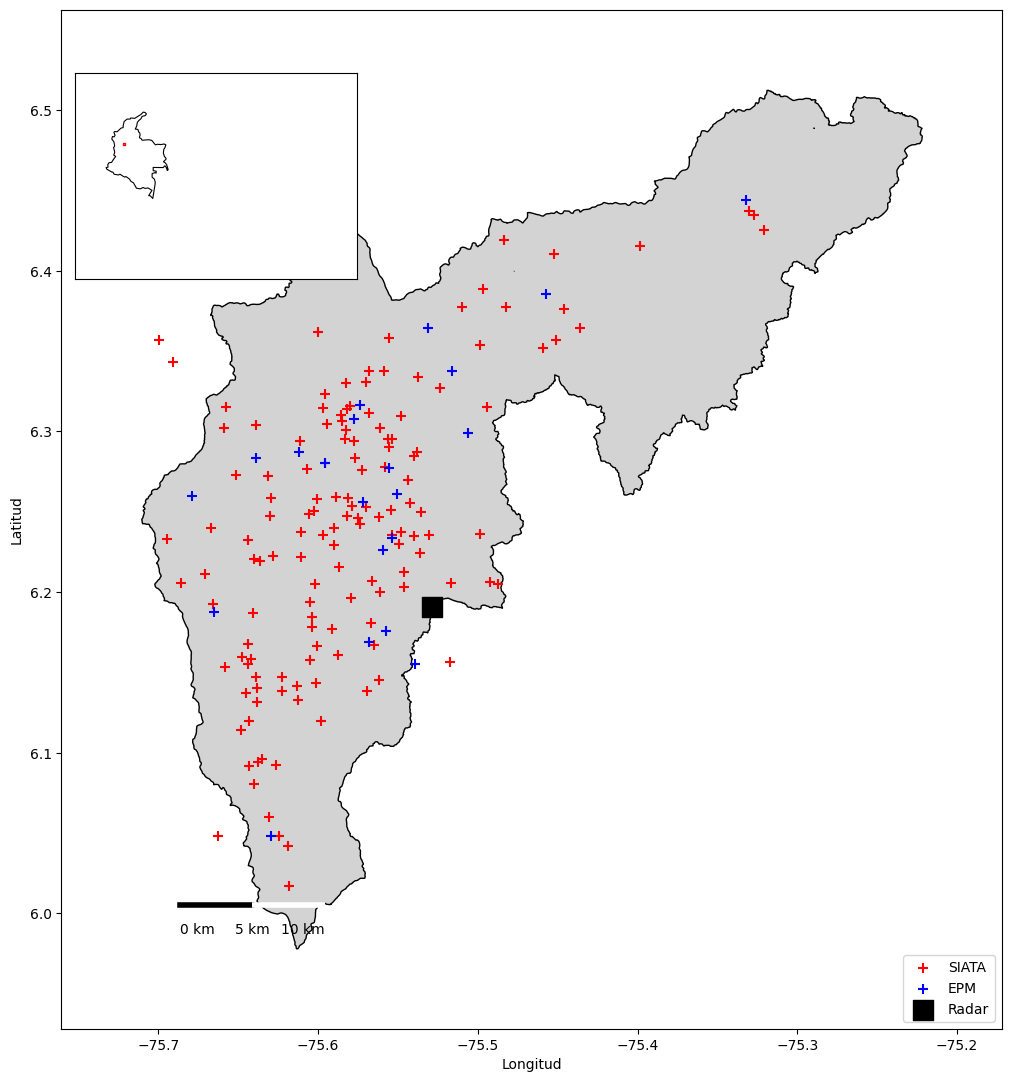

In [4]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="geopandas.datasets")
warnings.filterwarnings("ignore", category=UserWarning, message=".*tight_layout.*")

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from math import cos, radians

data = '../../DATA/'
# Cargar datos
boundary = gpd.read_file(f'{data}shape_files/aburra.geojson')
sidata = pd.read_csv(f'{data}coords_SIATA.csv')
epm = pd.read_csv(f'{data}coords_EPM.csv')
radar = pd.read_csv(f'{data}coords_radar.csv')

# 2. Crear GeoDataFrames
gdf_siata = gpd.GeoDataFrame(
    sidata,
    geometry=gpd.points_from_xy(sidata.Longitude, sidata.Latitude),
    crs='EPSG:4326'
)
gdf_epm = gpd.GeoDataFrame(
    epm,
    geometry=gpd.points_from_xy(epm.longitud, epm.latitud),
    crs='EPSG:4326'
)
gdf_radar = gpd.GeoDataFrame(
    radar,
    geometry=gpd.points_from_xy(radar.longitud, radar.latitud),
    crs='EPSG:4326'
)

# 3. Límites de la zona de estudio
minx, miny, maxx, maxy = boundary.total_bounds

# 4. Crear figura
fig, ax = plt.subplots(figsize=(10, 12), constrained_layout=True)

# 5. Plot: polígono de estudio
boundary.plot(ax=ax, facecolor='#d3d3d3', edgecolor='black', linewidth=1)

# 6. Plot: redes pluviométricas
gdf_siata.plot(ax=ax, marker='+', color='red', markersize=60, label='SIATA')
gdf_epm.plot(ax=ax, marker='+', color='blue', markersize=60, label='EPM')
# Plot: radar (aproximación)
gdf_radar.plot(ax=ax, marker='s', color='black', markersize=200, label='Radar')

# 7. Ejes y leyenda
ax.set_xlim(minx - 0.05, maxx + 0.05)
ax.set_ylim(miny - 0.05, maxy + 0.05)
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
ax.legend(loc='lower right', frameon=True)

# 8. Añadir barra de escala
def add_scale_bar(ax, length_km=10, location=(0.05, 0.05)):
    lat0 = (miny + maxy) / 2
    deg_per_km = 1 / (111.32 * cos(radians(lat0)))
    length_deg = length_km * deg_per_km

    x0 = minx + (maxx - minx) * location[0]
    y0 = miny + (maxy - miny) * location[1]
    half = length_deg / 2

    # dos segmentos
    ax.plot([x0, x0 + half], [y0, y0], lw=4, color='black')
    ax.plot([x0 + half, x0 + length_deg], [y0, y0], lw=4, color='white', solid_capstyle='butt')

    # etiquetas
    ax.text(x0, y0 - (maxy-miny)*0.02, '0 km', va='top')
    ax.text(x0 + half, y0 - (maxy-miny)*0.02, f'{length_km/2:.0f} km', va='top', ha='center')
    ax.text(x0 + length_deg, y0 - (maxy-miny)*0.02, f'{length_km} km', va='top', ha='right')

add_scale_bar(ax)

# 9. Inset: Colombia
# 9. Inset: Colombia (zoom norte de Suramérica)
data_path = gpd.datasets.get_path('naturalearth_lowres')
world = gpd.read_file(data_path)
# Filtrar Sudamérica y Colombia
sa = world[world.continent == 'South America']
colombia = sa[sa.name == 'Colombia']

axins = inset_axes(ax, width='30%', height='30%', loc='upper left', borderpad=1)
# Plotear Sudamérica en gris claro\msa.plot(ax=axins, color='#d3d3d3', edgecolor='white')
# Resaltar frontera de Colombia
colombia.boundary.plot(ax=axins, edgecolor='black', linewidth=0.8)
# Dibujar recuadro de la zona de estudio
GeoSeries = gpd.GeoSeries
GeoSeries([box(minx, miny, maxx, maxy)], crs='EPSG:4326')\
    .plot(ax=axins, edgecolor='red', facecolor='none', linewidth=1)
# Ajustar límites al norte de Suramérica
axins.set_xlim(-85, -30)
axins.set_ylim(-20, 20)
axins.set_xticks([])
axins.set_yticks([])


# 10. Guardar y mostrar
#fig.savefig('rain_gauge_networks_map.png', dpi=300)
plt.show()

